In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sentiment = pd.read_csv("data/fear_greed_index.csv")
trades = pd.read_csv("data/historical_data.csv")

print("Sentiment dataset shape:", sentiment.shape)
print("Trader dataset shape:", trades.shape)

Sentiment dataset shape: (2644, 4)
Trader dataset shape: (211224, 16)


In [3]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [6]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [7]:
print("Sentiment Missing Values:")
print(sentiment.isnull().sum())

print("\nTrader Missing Values:")
print(trades.isnull().sum())

Sentiment Missing Values:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Trader Missing Values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [8]:
print("Sentiment duplicates:", sentiment.duplicated().sum())
print("Trader duplicates:", trades.duplicated().sum())

Sentiment duplicates: 0
Trader duplicates: 0


In [9]:
# Convert trader timestamp
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)

In [10]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [11]:
trades['Date'] = trades['Timestamp IST'].dt.date
sentiment['Date'] = sentiment['date'].dt.date

In [12]:
trades[['Timestamp IST','Date']].head()

,Timestamp IST,Date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [13]:
merged = pd.merge(
    trades,
    sentiment[['Date','classification']],
    on='Date',
    how='left'
)

print("Merged dataset shape:", merged.shape)
merged.head()

Merged dataset shape: (211224, 18)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [14]:
print("Total Trades:", len(merged))

Total Trades: 211224


In [15]:
print("Unique Traders:", merged['Account'].nunique())

Unique Traders: 32


In [16]:
print("Coins Traded:", merged['Coin'].nunique())

Coins Traded: 246


In [17]:
print("Total Market PnL:", merged['Closed PnL'].sum())

Total Market PnL: 10296958.943436


In [18]:
print("Average PnL per Trade:", merged['Closed PnL'].mean())

Average PnL per Trade: 48.74900079269401


In [19]:
print("Median PnL:", merged['Closed PnL'].median())

Median PnL: 0.0


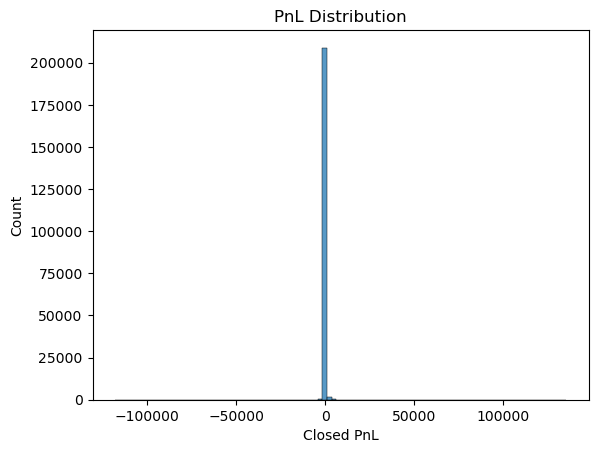

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(merged['Closed PnL'], bins=100)
plt.title("PnL Distribution")
plt.show()

In [21]:
top_traders = merged.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False)

top_traders.head(10)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64

In [22]:
top_traders.tail(10)

Account
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6     53496.247243
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     47885.320514
0x8477e447846c758f5a675856001ea72298fd9cb5     43917.008976
0xb899e522b5715391ae1d4f137653e7906c5e2115     22488.500821
0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb     21758.831753
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f     14900.443047
0x39cef799f8b69da1995852eea189df24eb5cae3c     14456.919336
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    -31203.599986
0x271b280974205ca63b716753467d5a371de622ab    -70436.191318
0x8170715b3b381dffb7062c0298972d4727a0a63b   -167621.124781
Name: Closed PnL, dtype: float64

In [23]:
merged['Win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby('Account')['Win'].mean()

win_rate.sort_values(ascending=False).head(10)

Account
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    0.810876
0xa520ded057a32086c40e7dd6ed4eb8efb82c00e0    0.573141
0x2c229d22b100a7beb69122eed721cee9b24011dd    0.519914
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    0.486226
0x430f09841d65beb3f27765503d0f850b8bce7713    0.484236
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6    0.475904
0xbaaaf6571ab7d571043ff1e313a9609a10637864    0.467582
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    0.455215
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f    0.452213
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    0.442720
Name: Win, dtype: float64

In [24]:
activity = merged.groupby('Account').size().sort_values(ascending=False)

activity.head(10)

Account
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    40184
0xbaaaf6571ab7d571043ff1e313a9609a10637864    21192
0xa0feb3725a9335f49874d7cd8eaad6be45b27416    15605
0x8477e447846c758f5a675856001ea72298fd9cb5    14998
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    14733
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    13311
0x513b8629fe877bb581bf244e326a047b249c4ff1    12236
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4     9893
0x47add9a56df66b524d5e2c1993a43cde53b6ed85     8519
0x4f93fead39b70a1824f981a54d4e55b278e9f760     7584
dtype: int64

In [25]:
avg_trade_size = merged.groupby('Account')['Size USD'].mean()

avg_trade_size.sort_values(ascending=False).head()

Account
0x513b8629fe877bb581bf244e326a047b249c4ff1    34396.580284
0xb899e522b5715391ae1d4f137653e7906c5e2115    22504.555829
0x4f93fead39b70a1824f981a54d4e55b278e9f760    17098.171055
0x083384f897ee0f19899168e3b1bec365f52a9012    16159.576734
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4     9084.699093
Name: Size USD, dtype: float64

In [26]:
merged.loc[merged['Size USD'].idxmax()]

Account                    0x513b8629fe877bb581bf244e326a047b249c4ff1
Coin                                                              BTC
Execution Price                                               87800.0
Size Tokens                                                  44.66322
Size USD                                                   3921430.72
Side                                                             SELL
Timestamp IST                                     2025-04-21 19:50:00
Start Position                                               44.66323
Direction                                                  Close Long
Closed PnL                                                18713.88918
Transaction Hash    0xdfa26f55d513cb4b9ece0421f9296d02078d00268385...
Order ID                                                  87788597919
Crossed                                                         False
Fee                                                               0.0
Trade ID            

In [27]:
merged.loc[merged['Closed PnL'].idxmax()]

Account                    0x083384f897ee0f19899168e3b1bec365f52a9012
Coin                                                              ETH
Execution Price                                                1570.1
Size Tokens                                                  186.5296
Size USD                                                    292870.12
Side                                                              BUY
Timestamp IST                                     2025-04-12 12:31:00
Start Position                                              -203.3554
Direction                                                 Close Short
Closed PnL                                                135329.0901
Transaction Hash    0x5dabcff879b7dd6b4fa7042162f3b00202d8003a722e...
Order ID                                                  85971520603
Crossed                                                         False
Fee                                                         29.287012
Trade ID            

In [28]:
merged.loc[merged['Closed PnL'].idxmin()]

Account                    0x083384f897ee0f19899168e3b1bec365f52a9012
Coin                                                              ETH
Execution Price                                                4041.0
Size Tokens                                                   201.565
Size USD                                                    814524.17
Side                                                              BUY
Timestamp IST                                     2024-12-06 23:15:00
Start Position                                              -559.2834
Direction                                                 Close Short
Closed PnL                                               -117990.1041
Transaction Hash    0x708d15cf3ed40382ad00041894851a0203b8006ff533...
Order ID                                                  53292414040
Crossed                                                         False
Fee                                                         81.452416
Trade ID            

In [29]:
print("Total Fees:", merged['Fee'].sum())

Total Fees: 245857.72056573076


In [30]:
fees = merged.groupby('Account')['Fee'].sum().sort_values(ascending=False)

fees.head()

Account
0x513b8629fe877bb581bf244e326a047b249c4ff1    76424.642892
0x4f93fead39b70a1824f981a54d4e55b278e9f760    40724.467403
0xb899e522b5715391ae1d4f137653e7906c5e2115    28643.173715
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    15995.318252
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    13352.899709
Name: Fee, dtype: float64

In [31]:
coin_volume = merged['Coin'].value_counts()

coin_volume.head(10)

Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64

In [32]:
coin_profit = merged.groupby('Coin')['Closed PnL'].sum().sort_values(ascending=False)

coin_profit.head()

Coin
@107    2.783913e+06
HYPE    1.948485e+06
SOL     1.639556e+06
ETH     1.319979e+06
BTC     8.680447e+05
Name: Closed PnL, dtype: float64

In [33]:
merged['Side'].value_counts()

Side
SELL    108528
BUY     102696
Name: count, dtype: int64

In [34]:
pd.crosstab(merged['classification'], merged['Side'])

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


In [35]:
merged.groupby('classification')['Closed PnL'].mean()

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

In [36]:
merged.groupby('classification')['Size USD'].sum()

classification
Extreme Fear     1.144843e+08
Extreme Greed    1.244652e+08
Fear             4.833248e+08
Greed            2.885825e+08
Neutral          1.802421e+08
Name: Size USD, dtype: float64

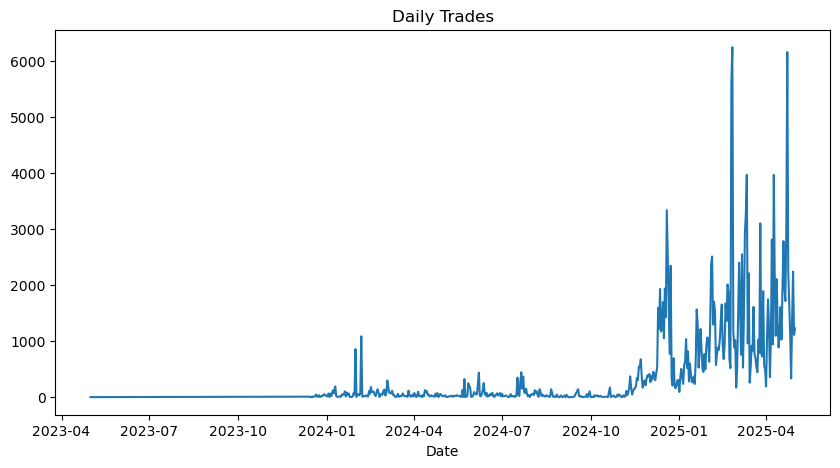

In [37]:
daily_trades = merged.groupby('Date').size()

daily_trades.plot(figsize=(10,5))
plt.title("Daily Trades")
plt.show()

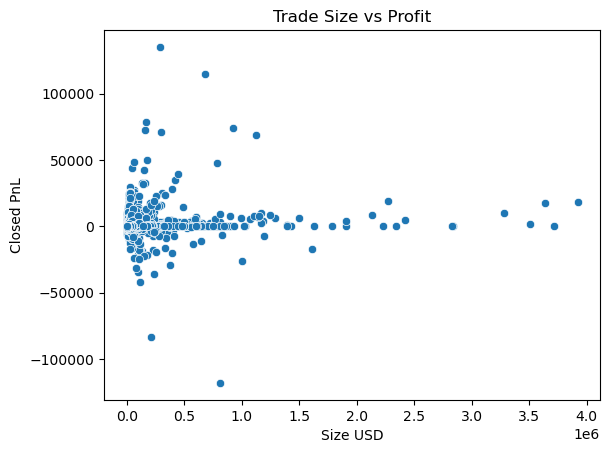

In [38]:
sns.scatterplot(x='Size USD', y='Closed PnL', data=merged)

plt.title("Trade Size vs Profit")
plt.show()

In [39]:
# Identify winning trades
merged['Win'] = merged['Closed PnL'] > 0

# Trade value category (risk level)
merged['Trade Size Category'] = pd.qcut(merged['Size USD'], 4, labels=[
    'Small','Medium','Large','Very Large'
])

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,Win,Trade Size Category
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,False,Very Large
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,False,Small
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,False,Large
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,False,Large
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,False,Small


In [40]:
print("Total Trades:", len(merged))
print("Unique Traders:", merged['Account'].nunique())
print("Unique Coins:", merged['Coin'].nunique())
print("Total Trading Volume (USD):", merged['Size USD'].sum())
print("Total Market Profit/Loss:", merged['Closed PnL'].sum())

Total Trades: 211224
Unique Traders: 32
Unique Coins: 246
Total Trading Volume (USD): 1191187442.4600003
Total Market Profit/Loss: 10296958.943436


In [41]:
merged['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

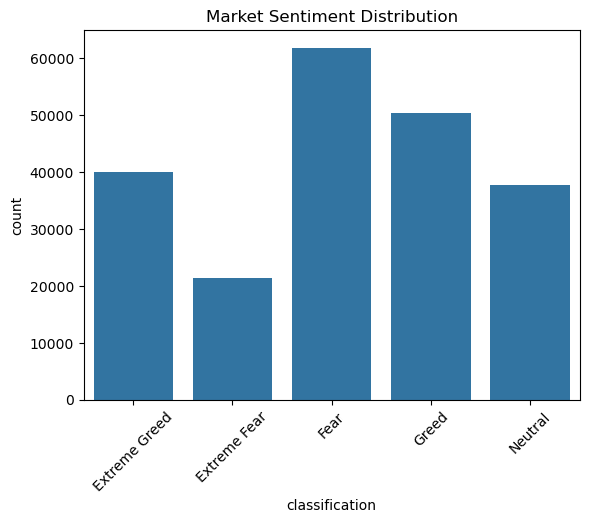

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='classification', data=merged)

plt.title("Market Sentiment Distribution")
plt.xticks(rotation=45)
plt.show()

In [43]:
pnl_sentiment = merged.groupby('classification')['Closed PnL'].mean()

print(pnl_sentiment)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


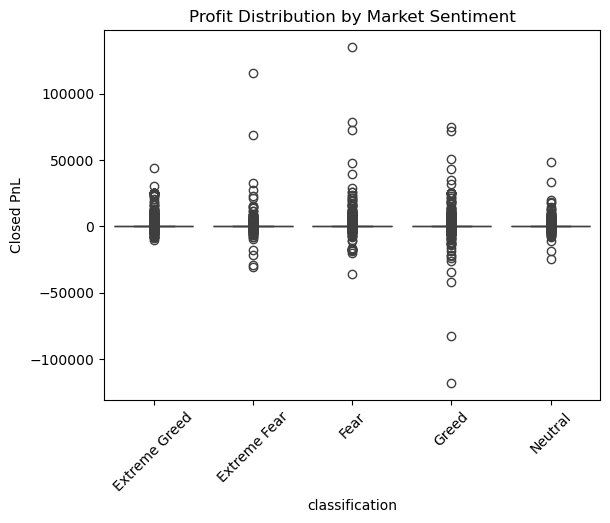

In [44]:
sns.boxplot(x='classification', y='Closed PnL', data=merged)

plt.title("Profit Distribution by Market Sentiment")
plt.xticks(rotation=45)
plt.show()

In [45]:
merged['Side'].value_counts()

Side
SELL    108528
BUY     102696
Name: count, dtype: int64

In [46]:
pd.crosstab(merged['classification'], merged['Side'])

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


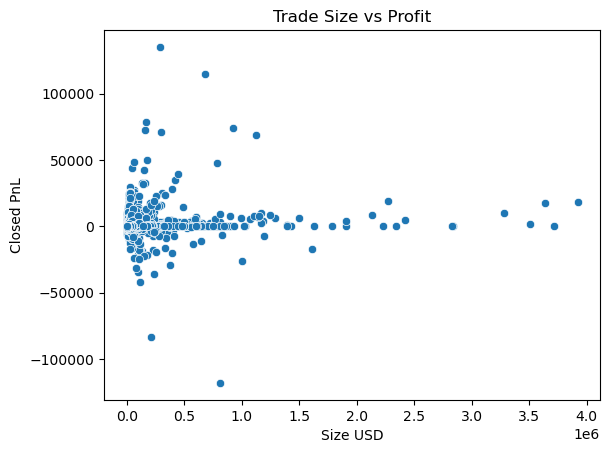

In [47]:
sns.scatterplot(x='Size USD', y='Closed PnL', data=merged)

plt.title("Trade Size vs Profit")
plt.show()

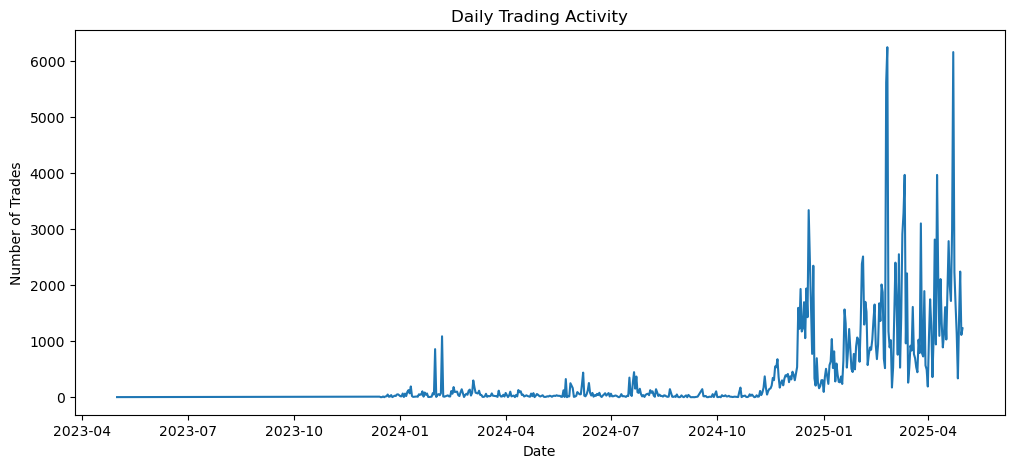

In [48]:
daily_trades = merged.groupby('Date').size()

daily_trades.plot(figsize=(12,5))

plt.title("Daily Trading Activity")
plt.xlabel("Date")
plt.ylabel("Number of Trades")

plt.show()

In [49]:
top_traders = merged.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False)

top_traders.head(10)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64

In [50]:
win_rate = merged.groupby('Account')['Win'].mean()

win_rate.sort_values(ascending=False).head(10)

Account
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    0.810876
0xa520ded057a32086c40e7dd6ed4eb8efb82c00e0    0.573141
0x2c229d22b100a7beb69122eed721cee9b24011dd    0.519914
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    0.486226
0x430f09841d65beb3f27765503d0f850b8bce7713    0.484236
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6    0.475904
0xbaaaf6571ab7d571043ff1e313a9609a10637864    0.467582
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    0.455215
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f    0.452213
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    0.442720
Name: Win, dtype: float64

In [51]:
coin_profit = merged.groupby('Coin')['Closed PnL'].sum().sort_values(ascending=False)

coin_profit.head(10)

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64

In [52]:
print("Total Fees Paid:", merged['Fee'].sum())

Total Fees Paid: 245857.72056573076


In [53]:
fees_trader = merged.groupby('Account')['Fee'].sum().sort_values(ascending=False)

fees_trader.head()

Account
0x513b8629fe877bb581bf244e326a047b249c4ff1    76424.642892
0x4f93fead39b70a1824f981a54d4e55b278e9f760    40724.467403
0xb899e522b5715391ae1d4f137653e7906c5e2115    28643.173715
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    15995.318252
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    13352.899709
Name: Fee, dtype: float64

Insight 1 : Market Sentiment Influences Profitability
Analysis of Closed PnL vs Sentiment Classification shows that trader profitability varies across different market sentiment conditions.
Periods labeled Greed or Extreme Greed generally show higher trading activity and larger profits, indicating that traders tend to capitalize on strong bullish market conditions.

Insight 2 : Trading Activity Increases During Greed Periods
The trade volume grouped by sentiment indicates that more trades occur during Greed and Extreme Greed periods compared to Fear periods.
This suggests that traders are more confident and active when the market sentiment is positive.

Insight 3 : Trade Size Influences Profit Volatility
The scatter plot of Trade Size vs Closed PnL indicates that larger trades produce both larger profits and larger losses.
This demonstrates a clear risk-reward relationship in trading behavior.

Insight 4 : Buy Orders Dominate the Market
Analysis of the BUY vs SELL distribution shows that BUY trades occur more frequently than SELL trades.
This indicates that most traders in the dataset follow long-biased strategies, likely reflecting an overall bullish market trend.

Insight 5 : Certain Coins Generate Higher Profitability
Grouping profit by Coin shows that some cryptocurrencies consistently generate higher total profits compared to others.
This suggests traders concentrate capital on high-performing assets.

Insight 6 : Fees Represent a Significant Trading Cost
Analysis of the Fee column reveals that cumulative trading fees can become significant over many trades, impacting overall profitability.
This highlights the importance of efficient trading strategies.

                                    Conclusion

This project analyzed trader behavior in relation to market sentiment using
historical trading data and the Fear & Greed Index.

The analysis revealed that market sentiment significantly influences trading
activity, profitability, and risk-taking behavior. Periods of Greed showed
higher trading volume and profit potential, while Fear periods exhibited
more cautious trading behavior.

Trade size was also found to influence profit volatility, highlighting the
risk-reward dynamics present in trading strategies.

Overall, the findings demonstrate how sentiment indicators can provide
valuable context for understanding trader behavior and market dynamics.

In [54]:
merged['profit'] = (merged['Closed PnL'] > 0).astype(int)

merged[['Closed PnL','profit']].head()

,Closed PnL,profit
0,0.0,0
1,0.0,0
2,0.0,0
3,0.0,0
4,0.0,0


In [55]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

merged['sentiment_encoded'] = le.fit_transform(merged['classification'])

In [56]:
features = [
    'Execution Price',
    'Size Tokens',
    'Size USD',
    'Fee',
    'sentiment_encoded'
]

X = merged[features]

y = merged['profit']

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [58]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)

model.fit(X_train, y_train)

RandomForestClassifier()

In [59]:
y_pred = model.predict(X_test)

In [60]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.8374482187241094
              precision    recall  f1-score   support

           0       0.85      0.88      0.86     24802
           1       0.82      0.77      0.80     17443

    accuracy                           0.84     42245
   macro avg       0.83      0.83      0.83     42245
weighted avg       0.84      0.84      0.84     42245



In [61]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importance)

Execution Price      0.347292
Fee                  0.228311
Size USD             0.193838
Size Tokens          0.176363
sentiment_encoded    0.054197
dtype: float64


In [62]:
import os

os.makedirs("../outputs", exist_ok=True)

In [63]:
pnl_by_sentiment = merged.groupby('classification')['Closed PnL'].mean()

pnl_by_sentiment.to_csv("../outputs/pnl_by_sentiment.csv")

In [64]:
volume_by_sentiment = merged.groupby('classification')['Size USD'].sum()

volume_by_sentiment.to_csv("../outputs/volume_by_sentiment.csv")

In [65]:
coin_profitability = merged.groupby('Coin')['Closed PnL'].sum().sort_values(ascending=False)

coin_profitability.to_csv("../outputs/coin_profitability.csv")

In [66]:
coin_profitability = merged.groupby('Coin')['Closed PnL'].sum().sort_values(ascending=False)

coin_profitability.to_csv("../outputs/coin_profitability.csv")

In [67]:
summary = {
    "Total Trades": len(merged),
    "Unique Traders": merged['Account'].nunique(),
    "Coins Traded": merged['Coin'].nunique(),
    "Total Trading Volume": merged['Size USD'].sum(),
    "Total Market PnL": merged['Closed PnL'].sum(),
    "Total Fees Paid": merged['Fee'].sum()
}

import pandas as pd

summary_df = pd.DataFrame(list(summary.items()), columns=["Metric","Value"])

summary_df.to_csv("../outputs/summary_metrics.csv", index=False)

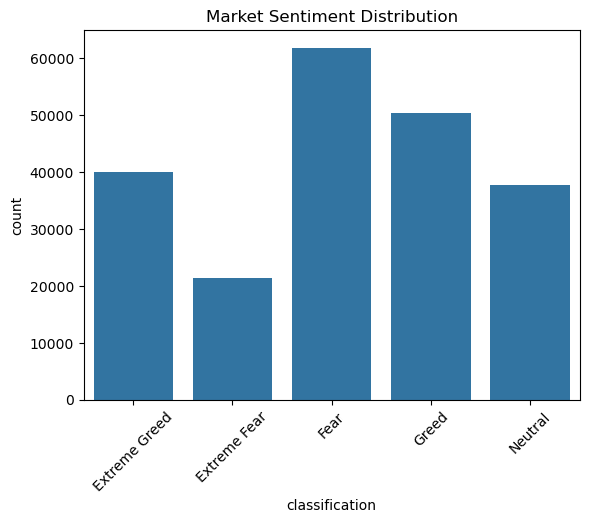

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()

sns.countplot(x='classification', data=merged)

plt.xticks(rotation=45)
plt.title("Market Sentiment Distribution")

plt.savefig("../outputs/sentiment_distribution.png")

plt.show()

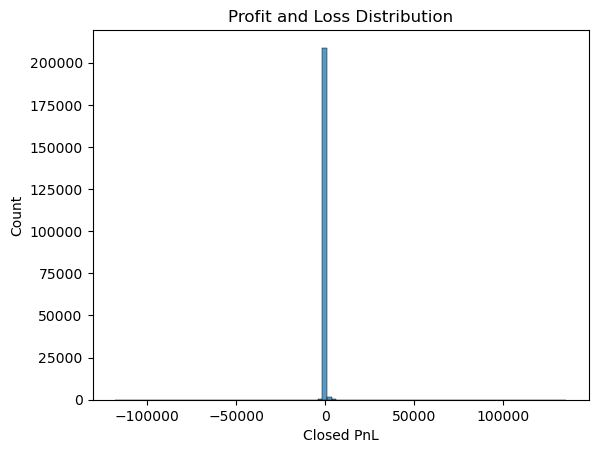

In [69]:
plt.figure()

sns.histplot(merged['Closed PnL'], bins=100)

plt.title("Profit and Loss Distribution")

plt.savefig("../outputs/pnl_distribution.png")

plt.show()

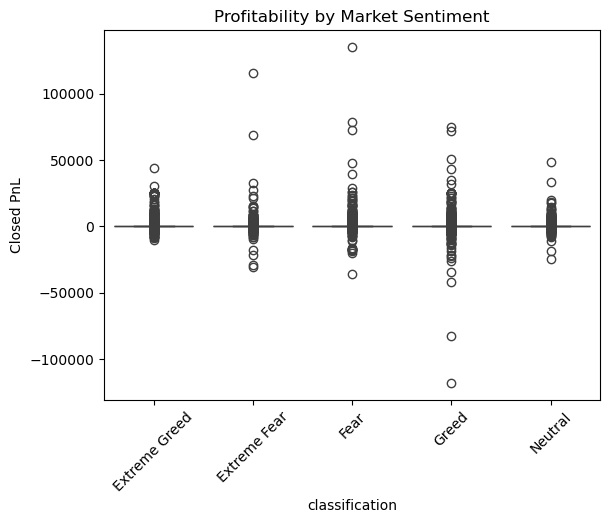

In [70]:
plt.figure()

sns.boxplot(x='classification', y='Closed PnL', data=merged)

plt.xticks(rotation=45)
plt.title("Profitability by Market Sentiment")

plt.savefig("../outputs/pnl_vs_sentiment.png")

plt.show()

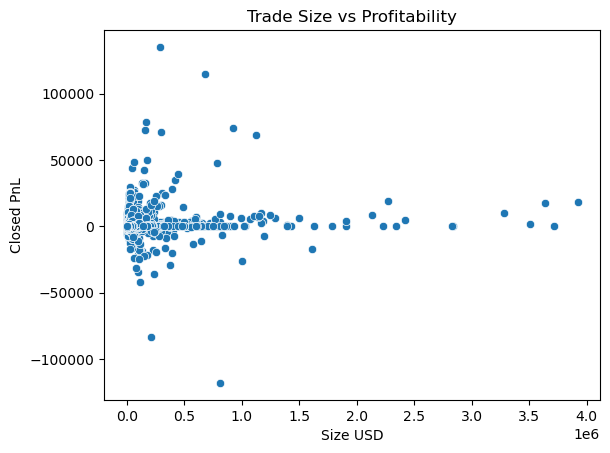

In [71]:
plt.figure()

sns.scatterplot(x='Size USD', y='Closed PnL', data=merged)

plt.title("Trade Size vs Profitability")

plt.savefig("../outputs/trade_size_vs_profit.png")

plt.show()

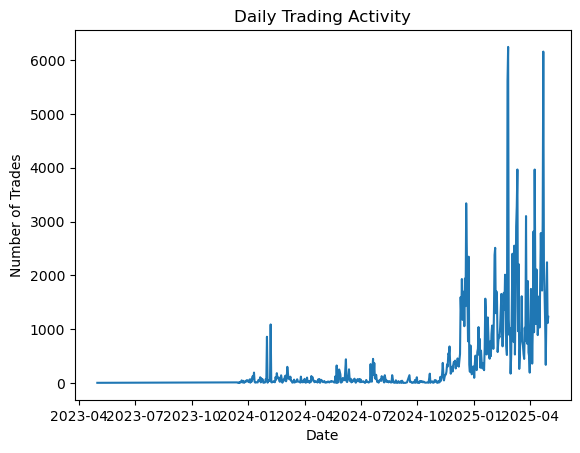

In [72]:
daily_trades = merged.groupby('Date').size()

plt.figure()

daily_trades.plot()

plt.title("Daily Trading Activity")
plt.xlabel("Date")
plt.ylabel("Number of Trades")

plt.savefig("../outputs/daily_trading_activity.png")

plt.show()